# 2. Following the TDR pipeline and incorporating source priors

This notebook uses the **production functions** in [`samueleronchini/gw_tdr`](https://github.com/samueleronchini/gw_tdr). It runs the pipeline on public GWOSC strain around **GRB 200228A** (Fermi trigger `bn200228291`), the O3 GRB identified in the paper as having the largest $D_{90}^{\rm TDR}$ and used for its TDR sky-map example. It uses the event's real Fermi/GBM HEALPix localization, then examines detector status, PSDs, antenna response, efficiency curves, TDR map, and result tables.

The trigger time (2020-02-28 06:58:33 UTC) and sky map are from the Fermi/GBM localization circular for GRB 200228A. The map is downloaded from the official HEASARC archive. As in the paper, the TDR is evaluated for assumed representative BNS/NSBH systems; it is a sensitivity calculation, not evidence that the GRB was produced by a compact binary.

**Requirements:** Python 3.11, an editable local installation of `gw_tdr` and its PyCBC/LALSuite/GWpy dependencies, and network access to GWOSC. The first full run downloads strain and can take several minutes. Outputs and the strain cache are written outside this tutorial tree under `~/.cache/gw_tdr_tutorial/`.

## 2.1 Install and orient yourself in the production code

This notebook requires Python >=3.11 and both the `gwosc` dependency and the local `gw_tdr` source package in the **same kernel environment**. In VS Code, choose the Python 3.11 TDR environment from the notebook kernel picker, then restart the kernel and rerun from the first cell. In a terminal configured for that exact environment, install the local repository with `python -m pip install -e /path/to/gw_tdr` (replace the path with your clone location); register the environment with `python -m pip install ipykernel` and `python -m ipykernel install --user --name gw-tdr --display-name "Python 3.11 (gw_tdr)"` if it is not already listed. The import-check cell reports the current interpreter and identifies whether `gwosc` or `targ_ac_git` is missing. Installing `gwosc` alone is not enough: `targ_ac_git` is provided by the local editable TDR installation. Do not install GW dependencies into the book environment just to build documentation.

| Analysis step | Production function(s) |
|---|---|
| Select observing-run configuration and read GWOSC strain | `gwosc_utils_snr_mf._get_run_config`, `_load_segment_from_cache`; `targ_range_snr_mf.load_strain_segments` |
| Estimate and validate PSDs; report usable IFOs | `pipeline_utils_snr_mf._make_psd_from_segment`, `_validate_psd_file`; `build_psds`, `report_ifos_used` |
| Create reference injections and compute optimal SNR | `aux_snr_mf.inject`; `targ_range_snr_mf.create_injections_and_snr`, `run_pycbc_optimal_snr` |
| Apply sky/orientation response and calculate detection fractions / D90 | `aux_snr_mf.compute_range`, `compute_map` |
| Draw sky samples and plot the TDR map | `targ_range_snr_mf.choose_localization_samples`; `aux_snr_mf.map_samples`, `plot_final` |

The public pipeline evaluates a fixed grid of BNS and NSBH masses (and EOS choices for NSBH). Its inclination prior is isotropic in solid angle, truncated to an interval. It accepts a fixed sky position or a HEALPix sky map; arbitrary joint mass–inclination–sky posterior samples are an exercise at the end, not an existing CLI feature.

In [1]:
import importlib.util
import json
import os
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import FileLink, Image, display
from pycbc.detector import Detector

missing_modules = [name for name in ("gwosc", "targ_ac_git") if importlib.util.find_spec(name) is None]
if sys.version_info < (3, 11) or missing_modules:
    raise RuntimeError(
        "This notebook needs Python >=3.11 with the TDR dependencies and local editable installation. "
        f"Current kernel: {sys.executable} (Python {sys.version.split()[0]}). "
        f"Missing modules: {missing_modules}. Install the local gw_tdr checkout into this kernel using "
        "python -m pip install -e /path/to/gw_tdr, then restart the kernel. See §2.1."
    )

from astropy.time import Time
from targ_ac_git import aux_snr_mf as tdr_aux
from targ_ac_git.pipeline_utils_snr_mf import PSDWrapper
from targ_ac_git.targ_range_snr_mf import (
    CHIRP_MASSES,
    choose_localization_samples,
)
from targ_ac_git.gwosc_utils_snr_mf import _get_run_config

def show_pdf(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(path)
    renderer = shutil.which("pdftoppm")
    if renderer is None:
        print(f"Inline PDF preview unavailable; open the plot file: {path}")
        display(FileLink(str(path)))
        return

    with tempfile.TemporaryDirectory() as temp_dir:
        image_prefix = Path(temp_dir) / path.stem
        subprocess.run(
            [renderer, "-f", "1", "-singlefile", "-png", "-r", "120", str(path), str(image_prefix)],
            check=True,
            capture_output=True,
            text=True,
        )
        display(Image(filename=f"{image_prefix}.png"))

print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)
print("TDR source:", __import__("targ_ac_git").__file__)

/opt/anaconda3/envs/TDR_ansh/lib/python3.11/importlib/__init__.py:126: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


/opt/anaconda3/envs/TDR_ansh/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.11.15
Interpreter: /opt/anaconda3/envs/TDR_ansh/bin/python
TDR source: /Users/samueleronchini/Desktop/dev_tdr/gw_tdr/targ_ac_git/__init__.py


## 2.2 Select the paper's O3 GRB and run TDR

The Fermi/GBM Final Real-time Localization circular reports GRB 200228A (`bn200228291`) at **2020-02-28 06:58:33 UTC** ([GCN 27247](https://gcn.nasa.gov/circulars/27247)). This lies in LVK O3b. We pass the corresponding HEALPix probability map directly to the TDR command; there is no synthetic or fixed sky position in this run. TDR selects the O3b detector configuration and fetches the configured 256 s public strain interval centered on the GRB time. Set `RUN_PIPELINE = False` only when reusing a completed output directory for the same trigger, sky map, and analysis settings.

In [2]:
EVENT = "GRB200228A"
TRIGGER_ID = "bn200228291"
T0_UTC = "2020-02-28T06:58:33"
T0 = Time(T0_UTC, format="isot", scale="utc").gps
SNR_THRESHOLD = 8.5
SNR_STATISTIC = "mf"  # matched-filter-like convention used by the TDR CLI
OUTPUT_ROOT = Path(os.environ.get("TDR_TUTORIAL_OUTPUT", Path.home() / ".cache" / "gw_tdr_tutorial" / EVENT)).expanduser()
RUN_DIR = OUTPUT_ROOT / "scan_t0p0000"
SKYMAP_URL = "https://heasarc.gsfc.nasa.gov/FTP/fermi/data/gbm/triggers/2020/bn200228291/quicklook/glg_healpix_all_bn200228291.fit"
SKYMAP_FILE = OUTPUT_ROOT / "glg_healpix_all_bn200228291.fit"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if not SKYMAP_FILE.is_file():
    from urllib.request import urlretrieve
    urlretrieve(SKYMAP_URL, SKYMAP_FILE)

run_config = _get_run_config(T0)
print(f"{EVENT} ({TRIGGER_ID}) trigger UTC: {T0_UTC}; GPS: {T0:.3f}")
print(f"Observing run: {run_config['name']}")
print(f"HEALPix localization: {SKYMAP_FILE}")
print(f"Results: {RUN_DIR}")

RUN_PIPELINE = os.environ.get("TDR_TUTORIAL_RUN", "1") == "1"
if RUN_PIPELINE:
    command = [
        sys.executable, "-m", "targ_ac_git.targ_range_snr_mf",
        "--output-dir", str(OUTPUT_ROOT),
        "--t0", str(T0),
        "--t-start", "0", "--t-end", "0", "--n-cpus", "1",
        "--skymap-file", str(SKYMAP_FILE),
        "--iota-min", "0", "--iota-max", "45",
        "--snr-threshold", str(SNR_THRESHOLD),
        "--snr-statistic", SNR_STATISTIC,
    ]
    subprocess.run(command, check=True)
else:
    assert (RUN_DIR / "ifos_used.json").is_file(), "No completed run found; set RUN_PIPELINE=True."

GRB200228A (bn200228291) trigger UTC: 2020-02-28T06:58:33; GPS: 1266908331.000
Observing run: O3b
HEALPix localization: /Users/samueleronchini/.cache/gw_tdr_tutorial/GRB200228A/glg_healpix_all_bn200228291.fit
Results: /Users/samueleronchini/.cache/gw_tdr_tutorial/GRB200228A/scan_t0p0000


The one-bin scan above runs the repository's normal trigger pipeline: it determines the observing run, loads public detector strain, estimates PSDs, creates the reference waveform injections, calls `pycbc_optimal_snr`, computes the BNS TDR map, evaluates BNS/NSBH efficiency curves, and writes JSON/PDF products. The directory is split into `scan_t0p0000/` (the trigger-time result) and the shared `gwosc_cache/`.

In [3]:
ifo_report = json.loads((RUN_DIR / "ifos_used.json").read_text())
online_ifos = ifo_report["used_ifos"]
status_rows = [
    {
        "IFO": ifo,
        "GWOSC strain available": status["strain_available"],
        "PSD valid": status["psd_ok"],
        "Used by TDR": status["usable"],
        "Reason": status["reason"],
    }
    for ifo, status in ifo_report["ifo_status"].items()
]
display(pd.DataFrame(status_rows).set_index("IFO"))
print("Network used by this run:", online_ifos)
print("TDR status record:", RUN_DIR / "ifos_used.json")

,GWOSC strain available,PSD valid,Used by TDR,Reason
IFO,,,,
H1,True,True,True,strain complete and PSD valid
L1,True,True,True,strain complete and PSD valid
V1,True,True,True,strain complete and PSD valid


Network used by this run: ['H1', 'L1', 'V1']
TDR status record: /Users/samueleronchini/.cache/gw_tdr_tutorial/GRB200228A/scan_t0p0000/ifos_used.json


### What “online” means in this run

For the trigger-time calculation, TDR reports an IFO as usable when its configured public strain segment is available and its PSD passes validation. This is the pipeline's data-usability decision; it is not an independent detector-state or full observing-duty-cycle query. The following compact chart visualizes the exact flags in TDR's own `ifos_used.json`, and the saved combined PDF is the pipeline's summary plot.

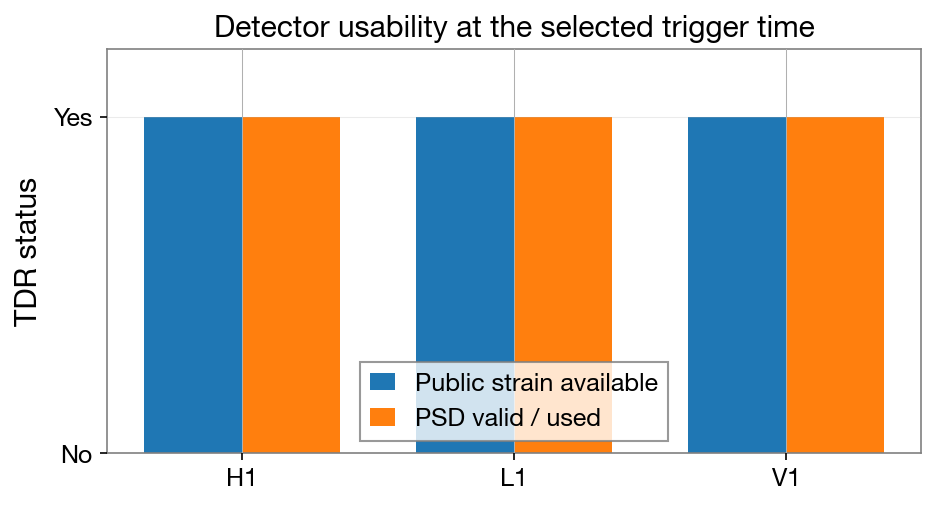

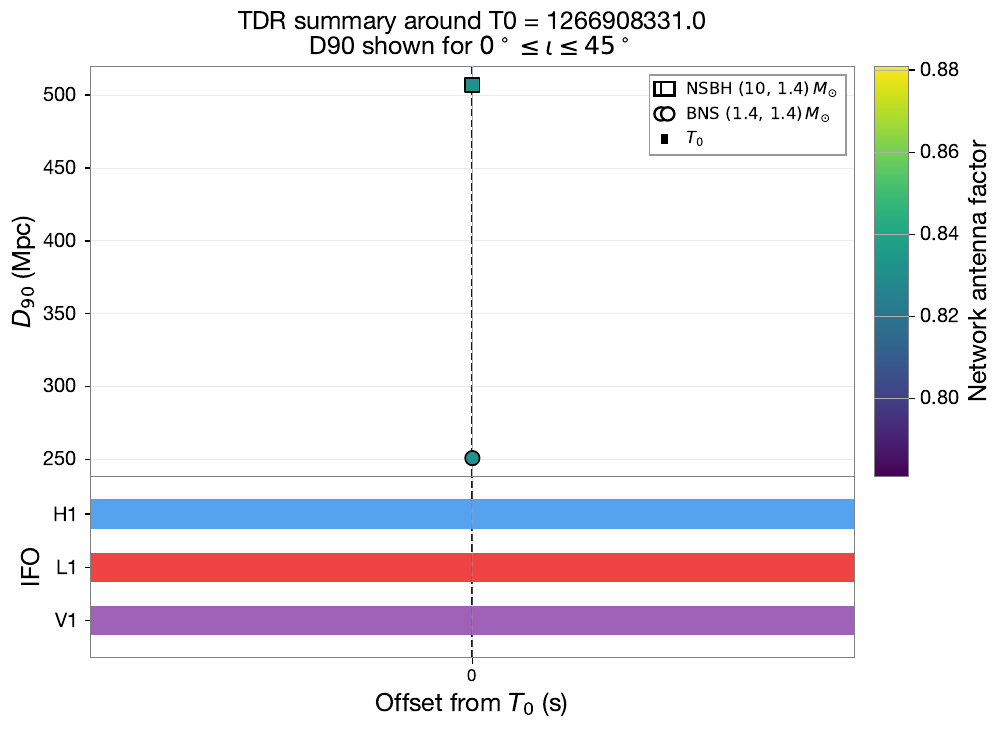

In [4]:
ifo_names = list(ifo_report["ifo_status"])
x = np.arange(len(ifo_names))
strain_ok = [ifo_report["ifo_status"][ifo]["strain_available"] for ifo in ifo_names]
psd_ok = [ifo_report["ifo_status"][ifo]["psd_ok"] for ifo in ifo_names]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(x - 0.18, strain_ok, width=0.36, label="Public strain available")
ax.bar(x + 0.18, psd_ok, width=0.36, label="PSD valid / used")
ax.set(xticks=x, xticklabels=ifo_names, yticks=[0, 1], yticklabels=["No", "Yes"], ylim=(0, 1.2), ylabel="TDR status")
ax.set_title("Detector usability at the selected trigger time")
ax.legend()
ax.grid(axis="y", alpha=0.25)
status_plot = RUN_DIR / "ifo_usability.png"
fig.savefig(status_plot, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(status_plot)))

summary_pdf = OUTPUT_ROOT / "D90_and_IFO_windows_combined.pdf"
if summary_pdf.is_file():
    show_pdf(summary_pdf)

## 2.3 Inspect the detector noise used in the calculation

TDR estimates each PSD from the downloaded strain using the production Welch configuration (16 s segments, 8 s overlap), validates and saves a two-column frequency/PSD file, then passes those files to `pycbc_optimal_snr`. Here we reload those exact PSD files into the repository's plotting wrapper and call its `plot_psd` function.

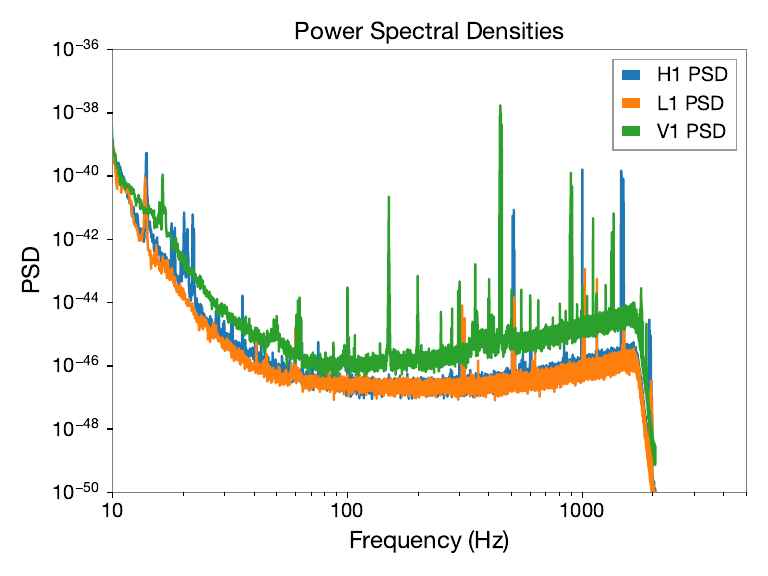

In [5]:
psd_objects = [
    PSDWrapper(np.loadtxt(RUN_DIR / f"{ifo.lower()}_psd.txt"))
    for ifo in online_ifos
]
tdr_aux.plot_psd(psd_objects, str(RUN_DIR), ifos=online_ifos)
show_pdf(RUN_DIR / "psd_plot.pdf")

## 2.4 Plot the live network antenna response

The plots use PyCBC `Detector.antenna_pattern`, the same detector geometry used by the TDR distance-rescaling calculations, evaluated at the GRB trigger time. Each panel shows $\sqrt{F_+^2+F_\times^2}$ for polarization angle $\psi=0$; it is not yet the complete source response, which also weights $F_+$ and $F_\times$ by inclination and polarization. `compute_antennamap` is TDR's own network helper and selects the sky direction maximizing its summed $F_+^2+F_\times^2$ criterion for the reference injections.

TDR antenna-max direction [deg]: 168.75 38.68218745348943
TDR antenna factor over the sampled GRB localization: {'antenna_factor': 0.8314149910286092, 'antenna_factor_mode': 'max_over_grb_skymap_samples', 'antenna_factor_ra_deg': 351.65322580645164, 'antenna_factor_dec_deg': -43.40685848593699, 'antenna_factor_definition': 'sqrt(sum_i(Fplus_i^2 + Fcross_i^2) / N_ifo)'}


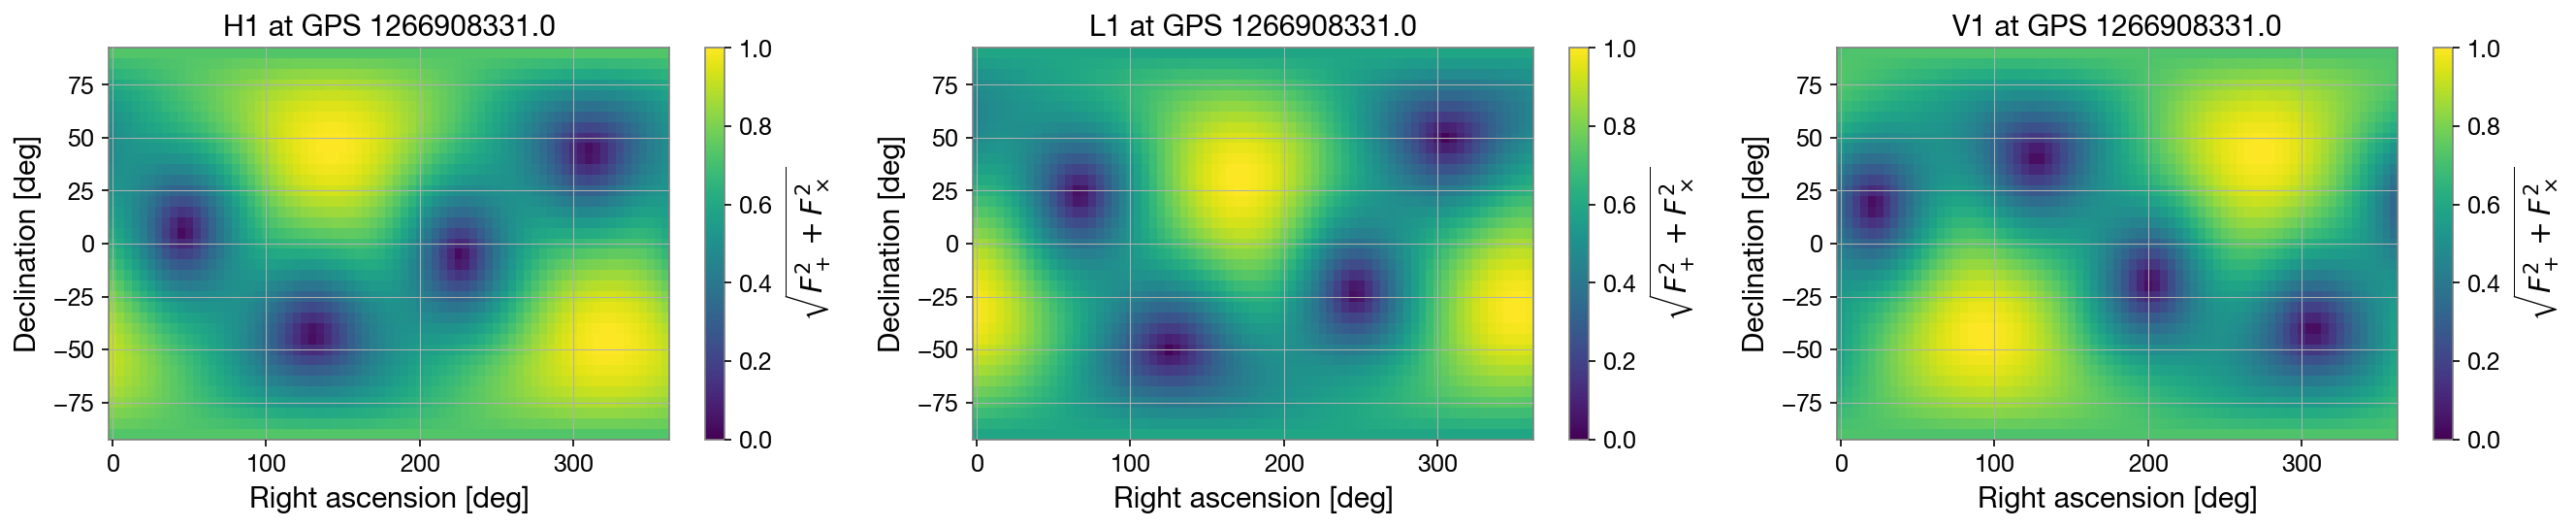

In [6]:
ra_axis = np.linspace(0, 2 * np.pi, 73)
dec_axis = np.linspace(-np.pi / 2, np.pi / 2, 37)
ra_mesh, dec_mesh = np.meshgrid(ra_axis, dec_axis)
fig, axes = plt.subplots(1, len(online_ifos), figsize=(6 * len(online_ifos), 3.8), squeeze=False)

for ax, ifo in zip(axes[0], online_ifos):
    detector = Detector(ifo)
    antenna_values = np.vectorize(detector.antenna_pattern, otypes=[float, float])(
        ra_mesh, dec_mesh, 0.0, T0
    )
    f_plus, f_cross = antenna_values
    response = np.hypot(f_plus, f_cross)
    image = ax.pcolormesh(np.rad2deg(ra_mesh), np.rad2deg(dec_mesh), response, shading="auto", vmin=0, vmax=1)
    ax.set(title=f"{ifo} at GPS {T0:.1f}", xlabel="Right ascension [deg]", ylabel="Declination [deg]")
    fig.colorbar(image, ax=ax, label=r"$\sqrt{F_+^2+F_\times^2}$")

ra_best, dec_best = tdr_aux.compute_antennamap(online_ifos, T0)
ra_samples, dec_samples, skymap = choose_localization_samples(
    None, None, str(SKYMAP_FILE), ra_best, dec_best
)
antenna_info = tdr_aux.compute_localization_antenna_factor(
    online_ifos, T0, ra_samples, dec_samples, mode="max_over_grb_skymap_samples"
)
print("TDR antenna-max direction [deg]:", np.rad2deg(ra_best), np.rad2deg(dec_best))
print("TDR antenna factor over the sampled GRB localization:", antenna_info)
plt.tight_layout()
antenna_plot = RUN_DIR / "ifo_antenna_response.png"
fig.savefig(antenna_plot, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(antenna_plot)))

## 2.5 Recompute efficiency curves for mass and inclination choices

The first CLI run calculates the default mass grid and the requested $0$–$45^\circ$ inclination prior. Now we call the real `compute_range` function again, reusing the optimal-SNR HDF files produced by the actual PyCBC injections. This comparison changes only the isotropic inclination interval; the GRB sky map, trigger-time detector network, strain-derived PSDs, threshold, and waveform/SNR reference files stay fixed.

For each reference injection, `compute_range` rescales detector SNR using PyCBC effective distances at the source and reference locations, combines detector contributions in quadrature, samples the requested inclination prior, and measures the fraction above threshold as distance increases. $D_{90}$ is the distance where that fraction reaches 90%. The repository's `mf` statistic is its matched-filter-like conversion from optimal SNR; it is not a measured search FAR.

In [7]:
iota_ranges = [
    {"label": f"0-{upper}", "iota_min": 0.0, "iota_max": np.deg2rad(upper)}
    for upper in (30, 45, 90)
]
np.random.seed(12345 + int(round(T0)))
tdr_aux.compute_range(
    ra_samples,
    dec_samples,
    online_ifos,
    CHIRP_MASSES,
    str(RUN_DIR),
    iota_ranges,
    SNR_THRESHOLD,
    "matched_filter" if SNR_STATISTIC == "mf" else "optimal",
    antenna_info=antenna_info,
)
print("Efficiency curves and refreshed result JSON written under", RUN_DIR)

Efficiency curves and refreshed result JSON written under /Users/samueleronchini/.cache/gw_tdr_tutorial/GRB200228A/scan_t0p0000


In [8]:
def read_tdr_table(path):
    """Flatten the production JSON schema into one row per mass/prior pair."""
    payload = json.loads(Path(path).read_text())
    rows = []
    for source_class, systems in payload.items():
        for mass_label, entry in systems.items():
            for prior_label, value in entry["tdr"].items():
                rows.append({
                    "Source class": source_class.upper(),
                    "Mass pair": mass_label,
                    "Inclination prior": prior_label,
                    "IFO network": ",".join(entry.get("online_ifos", [])),
                    "SNR statistic": entry.get("snr_statistic", SNR_STATISTIC),
                    "Threshold": entry.get("snr_threshold", SNR_THRESHOLD),
                    "D90 [Mpc]": value["D90_Mpc"],
                })
    return pd.DataFrame(rows)

bns_table = read_tdr_table(RUN_DIR / "results_bns.json")
nsbh_table = read_tdr_table(RUN_DIR / "results_nsbh.json")
tdr_table = pd.concat([bns_table, nsbh_table], ignore_index=True)
display(tdr_table)

,Source class,Mass pair,Inclination prior,IFO network,SNR statistic,Threshold,D90 [Mpc]
0,BNS,"m1=1, m2=1",0-30,"H1,L1,V1",matched_filter,8.5,218.251194
1,BNS,"m1=1, m2=1",0-45,"H1,L1,V1",matched_filter,8.5,190.441358
2,BNS,"m1=1, m2=1",0-90,"H1,L1,V1",matched_filter,8.5,81.243809
3,BNS,"m1=1.4, m2=1.4",0-30,"H1,L1,V1",matched_filter,8.5,289.592292
4,BNS,"m1=1.4, m2=1.4",0-45,"H1,L1,V1",matched_filter,8.5,251.403786
5,BNS,"m1=1.4, m2=1.4",0-90,"H1,L1,V1",matched_filter,8.5,104.722893
6,BNS,"m1=2.0, m2=2.0",0-30,"H1,L1,V1",matched_filter,8.5,388.201331
7,BNS,"m1=2.0, m2=2.0",0-45,"H1,L1,V1",matched_filter,8.5,335.862836
8,BNS,"m1=2.0, m2=2.0",0-90,"H1,L1,V1",matched_filter,8.5,139.428606
9,NSBH,"m1=5, m2=1",0-30,"H1,L1,V1",matched_filter,8.5,387.870908


These tables are flattened from the pipeline's own `results_bns.json` and `results_nsbh.json`; NSBH values follow the repository's EOS-averaging convention. The PDFs below are also produced by the repository's `compute_range` plotting logic. Compare systems under the same GRB sky localization and compare inclination priors at fixed component masses; do not read the result as an astrophysical exclusion without a corresponding search analysis.

bns_targeted_range.pdf


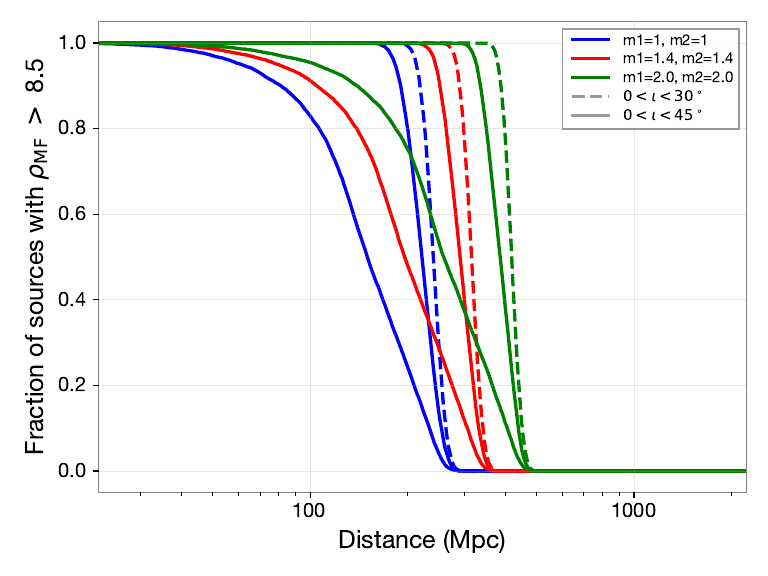

nsbh_targeted_range.pdf


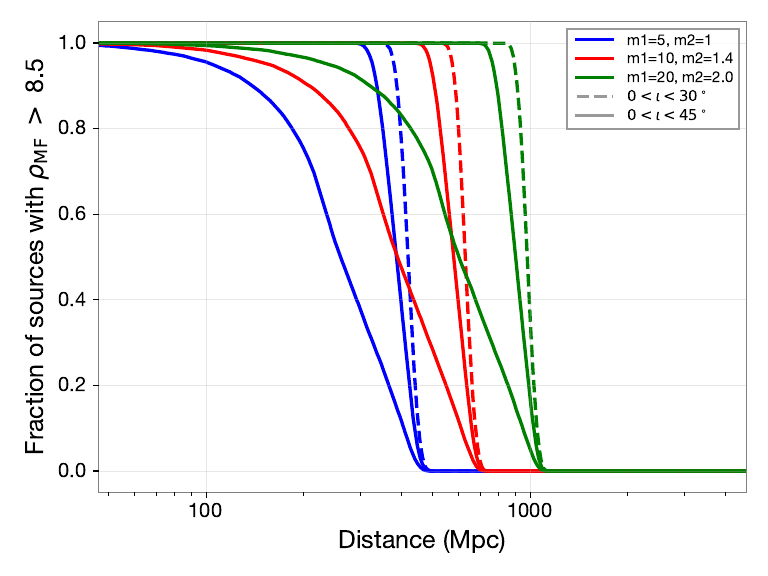

In [9]:
for filename in ("bns_targeted_range.pdf", "nsbh_targeted_range.pdf"):
    print(filename)
    show_pdf(RUN_DIR / filename)

## 2.6 Inspect the TDR sky map

During the pipeline run, `compute_map("bns", 1.4, 1.4, ...)` evaluated the 90%-detectable distance over TDR's HEALPix grid using the actual reference-SNR HDF file, detector geometry, trigger time, selected inclination prior, and SNR threshold. `plot_final` renders that FITS map in the same format used by the repository. The map is a sensitivity map over sky position, not a posterior probability map.

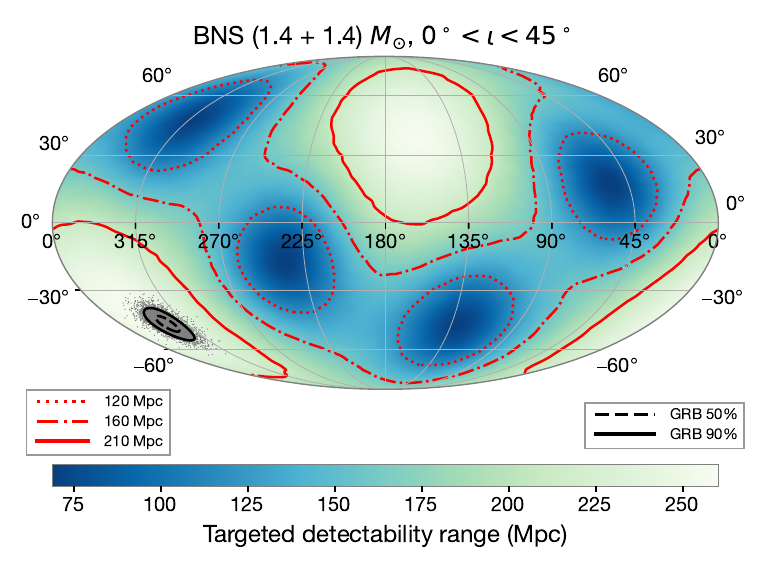

In [10]:
range_map = RUN_DIR / "range_map_bns_m1_1.4_m2_1.4.fits"
assert range_map.is_file(), f"TDR map not found: {range_map}"
tdr_aux.plot_final(
    str(RUN_DIR), str(range_map), str(skymap),
    [ra_samples, dec_samples],
    iota_ranges[1]["iota_min"], iota_ranges[1]["iota_max"],
)
show_pdf(RUN_DIR / "range_map_bns_m1_1.4_m2_1.4.pdf")

## 2.7 Exercise: compare another source sky map

The main calculation already propagates the paper's GRB 200228A localization through TDR. To compare another real GRB/source localization, supply its HEALPix FITS file (with `PROB` or `PROBABILITY`). The production helper `choose_localization_samples` delegates to TDR's `map_samples`, which normalizes pixel probabilities and draws sky samples. The code below passes those RA/Dec draws to production `compute_range`, saves results separately, and uses TDR's `plot_final` to overlay the alternate localization on the TDR map.

**Exercise:** compare the paper's GRB map-conditioned table with a second sky-map-conditioned table. How does probability on less-sensitive parts of the sky change the fraction-versus-distance curves? Preserve the paired result directories to compare both outputs.

In [11]:
ALTERNATE_SKYMAP_FILE = None  # Set to Path("/path/to/another_localization.fits") to run this exercise.

if ALTERNATE_SKYMAP_FILE is None:
    print("Exercise not run: set ALTERNATE_SKYMAP_FILE to another real HEALPix FITS localization.")
else:
    skymap_path = Path(ALTERNATE_SKYMAP_FILE).expanduser()
    if not skymap_path.is_file():
        raise FileNotFoundError(skymap_path)
    ra_samples, dec_samples, skymap = choose_localization_samples(
        None, None, str(skymap_path), ra_best, dec_best
    )
    skymap_dir = OUTPUT_ROOT / f"skymap_{skymap_path.stem}"
    skymap_dir.mkdir(parents=True, exist_ok=True)
    shutil.copytree(RUN_DIR / "results", skymap_dir / "results", dirs_exist_ok=True)
    antenna_info_skymap = tdr_aux.compute_localization_antenna_factor(
        online_ifos, T0, ra_samples, dec_samples, mode="max_over_grb_skymap_samples"
    )
    np.random.seed(12345 + int(round(T0)))
    tdr_aux.compute_range(
        ra_samples, dec_samples, online_ifos, CHIRP_MASSES, str(skymap_dir),
        iota_ranges, SNR_THRESHOLD,
        "matched_filter" if SNR_STATISTIC == "mf" else "optimal",
        antenna_info=antenna_info_skymap,
    )
    tdr_aux.plot_final(
        str(skymap_dir), str(range_map), str(skymap), [ra_samples, dec_samples],
        iota_ranges[1]["iota_min"], iota_ranges[1]["iota_max"],
    )
    display(read_tdr_table(skymap_dir / "results_bns.json"))
    show_pdf(skymap_dir / "range_map_bns_m1_1.4_m2_1.4.pdf")

Exercise not run: set ALTERNATE_SKYMAP_FILE to another real HEALPix FITS localization.


## 2.8 Exercise: propagate joint mass, inclination, and sky samples

The current production calculation samples isotropic inclination within a requested interval, reads a fixed set of reference mass-pair injections, and accepts sky samples independently from a localization map. It does **not** accept arbitrary correlated posterior rows. A research extension should preserve each posterior tuple $(m_1,m_2,\iota,\mathrm{RA},\mathrm{Dec})$ and its weight rather than drawing each marginal independently.

Start with a CSV of posterior samples with columns `m1`, `m2`, `iota_rad`, `ra_deg`, `dec_deg` and optional `weight`. The next cell creates an **illustrative** sample set by drawing an independent Gaussian for every required parameter; these are not measured GRB posterior samples and have no cross-parameter correlations. Change the means and widths, or replace the generated CSV with real paired posterior samples. The following cell validates and resamples **whole rows**, preserving any correlations present in the chosen CSV, and plots the resulting parameter marginals and joint mass/sky distributions. These are source-sample plots, not TDR efficiency curves or a TDR sensitivity map: the current production functions do not yet propagate arbitrary joint mass/inclination/sky rows. The coding task is to adapt `targ_range_snr_mf.create_injections_and_snr` and `aux_snr_mf.compute_range` so waveform/SNR references support the mass samples and every row's own sky/orientation; calculate each row's threshold horizon and its weighted detection fraction, then report the 10th percentile horizon as $D_{90}$. Add tests for normalized/nonnegative weights, parameter bounds, and invariance under duplicating equally weighted samples.

Do not pass these samples to the current `compute_range` as if it already accepted them: its signature and sampler do not.

In [16]:
# Illustrative independent Gaussian marginals; these are not measured GRB posterior samples.
N_GAUSSIAN_SAMPLES = 5_000
rng = np.random.default_rng(20261008)

def truncated_normal(mean, sigma, size, lower, upper, rng):
    draws = np.empty(size)
    filled = 0
    while filled < size:
        candidates = rng.normal(mean, sigma, size=max(100, 2 * (size - filled)))
        accepted = candidates[(candidates >= lower) & (candidates <= upper)]
        count = min(len(accepted), size - filled)
        draws[filled:filled + count] = accepted[:count]
        filled += count
    return draws

# Draw BNS component masses jointly and retain only physical mass ordering.
m1_draws = []
m2_draws = []
while len(m1_draws) < N_GAUSSIAN_SAMPLES:
    batch_size = 2 * (N_GAUSSIAN_SAMPLES - len(m1_draws))
    m1_batch = rng.normal(10.46, 0.12, batch_size)
    m2_batch = rng.normal(1.30, 0.10, batch_size)
    valid = (
        (m1_batch >= 1.0) & (m1_batch <= 25.0)
        & (m2_batch >= 1.0) & (m2_batch <= 2.0)
        & (m1_batch >= m2_batch)
    )
    m1_draws.extend(m1_batch[valid].tolist())
    m2_draws.extend(m2_batch[valid].tolist())
m1_draws = np.asarray(m1_draws[:N_GAUSSIAN_SAMPLES])
m2_draws = np.asarray(m2_draws[:N_GAUSSIAN_SAMPLES])

# Center the sky prior on the circular mean of the GRB localization samples.
ra_center = np.arctan2(np.mean(np.sin(ra_samples)), np.mean(np.cos(ra_samples))) % (2 * np.pi)
dec_center = float(np.mean(dec_samples))
ra_sigma = np.deg2rad(2.0) / max(abs(np.cos(dec_center)), 0.1)  # local tangent-plane approximation
ra_draws = (ra_center + rng.normal(0.0, ra_sigma, N_GAUSSIAN_SAMPLES)) % (2 * np.pi)
dec_draws = truncated_normal(dec_center, np.deg2rad(2.0), N_GAUSSIAN_SAMPLES, -np.pi / 2, np.pi / 2, rng)
iota_draws = truncated_normal(np.deg2rad(30.0), np.deg2rad(10.0), N_GAUSSIAN_SAMPLES, 0.0, np.pi, rng)

gaussian_samples = pd.DataFrame({
    "m1": m1_draws,
    "m2": m2_draws,
    "iota_rad": iota_draws,
    "ra_deg": np.rad2deg(ra_draws),
    "dec_deg": np.rad2deg(dec_draws),
})
GAUSSIAN_SAMPLE_FILE = OUTPUT_ROOT / "gaussian_joint_source_samples.csv"
gaussian_samples.to_csv(GAUSSIAN_SAMPLE_FILE, index=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
labels = (r"$m_1$ [$M_\odot$]", r"$m_2$ [$M_\odot$]", r"$\iota$ [rad]", "RA [deg]", "Dec [deg]")
for ax, column, label in zip(axes, gaussian_samples.columns, labels):
    ax.hist(gaussian_samples[column], bins=30, density=True, color="steelblue", alpha=0.8)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
fig.tight_layout()
display(fig)
plt.close(fig)
print(f"Created {len(gaussian_samples)} Gaussian source samples: {GAUSSIAN_SAMPLE_FILE}")
display(gaussian_samples.head())

<Figure size 1600x300 with 5 Axes>

Created 5000 Gaussian source samples: /Users/samueleronchini/.cache/gw_tdr_tutorial/GRB200228A/gaussian_joint_source_samples.csv


,m1,m2,iota_rad,ra_deg,dec_deg
0,10.458762,1.232542,0.467885,330.545362,-45.848606
1,10.298313,1.344980,0.357804,331.301309,-43.988493
2,10.732957,1.394992,0.511255,328.012185,-45.604963
3,10.443762,1.197908,0.397474,326.514092,-47.010286
4,10.456127,1.187059,0.383372,328.410688,-44.178644


In [17]:
POSTERIOR_CSV = GAUSSIAN_SAMPLE_FILE  # Replace with a real posterior CSV to use external samples.
joint_draws = None

if POSTERIOR_CSV is None:
    print("Exercise not run: provide real, paired source-posterior samples in a CSV.")
else:
    posterior = pd.read_csv(Path(POSTERIOR_CSV).expanduser())
    required = {"m1", "m2", "iota_rad", "ra_deg", "dec_deg"}
    missing = required - set(posterior.columns)
    if missing:
        raise ValueError(f"Posterior is missing required columns: {sorted(missing)}")
    weights = posterior["weight"].to_numpy(dtype=float) if "weight" in posterior else np.ones(len(posterior))
    if len(posterior) == 0 or not np.all(np.isfinite(weights)) or np.any(weights < 0) or weights.sum() <= 0:
        raise ValueError("Posterior must have rows and finite, nonnegative weights with positive sum.")
    rng = np.random.default_rng(417)
    row_indices = rng.choice(len(posterior), size=10_000, replace=True, p=weights / weights.sum())
    joint_draws = posterior.iloc[row_indices].reset_index(drop=True)
    print(f"Resampled {len(joint_draws)} complete joint tuples; correlations are retained.")
    display(joint_draws.head())
    print("Next: extend the production injection/reference-SNR and weighted efficiency calculation as specified above.")

Resampled 10000 complete joint tuples; correlations are retained.


,m1,m2,iota_rad,ra_deg,dec_deg
0,10.450149,1.343145,0.480540,325.229537,-40.697526
1,10.496158,1.291303,0.671820,329.489938,-48.473054
2,10.466605,1.321608,0.509514,327.231836,-48.459995
3,10.372715,1.361028,0.359613,325.438751,-47.447588
4,10.424084,1.388577,0.453238,328.633230,-44.613942


Next: extend the production injection/reference-SNR and weighted efficiency calculation as specified above.


### Plot the custom source samples

These plots show the selected joint sample set (the Gaussian example by default, or the CSV you configured above). The marginals summarize each parameter; the scatter panels show paired values from the same rows. They visualize the source samples only, not a TDR efficiency curve or sky sensitivity map.

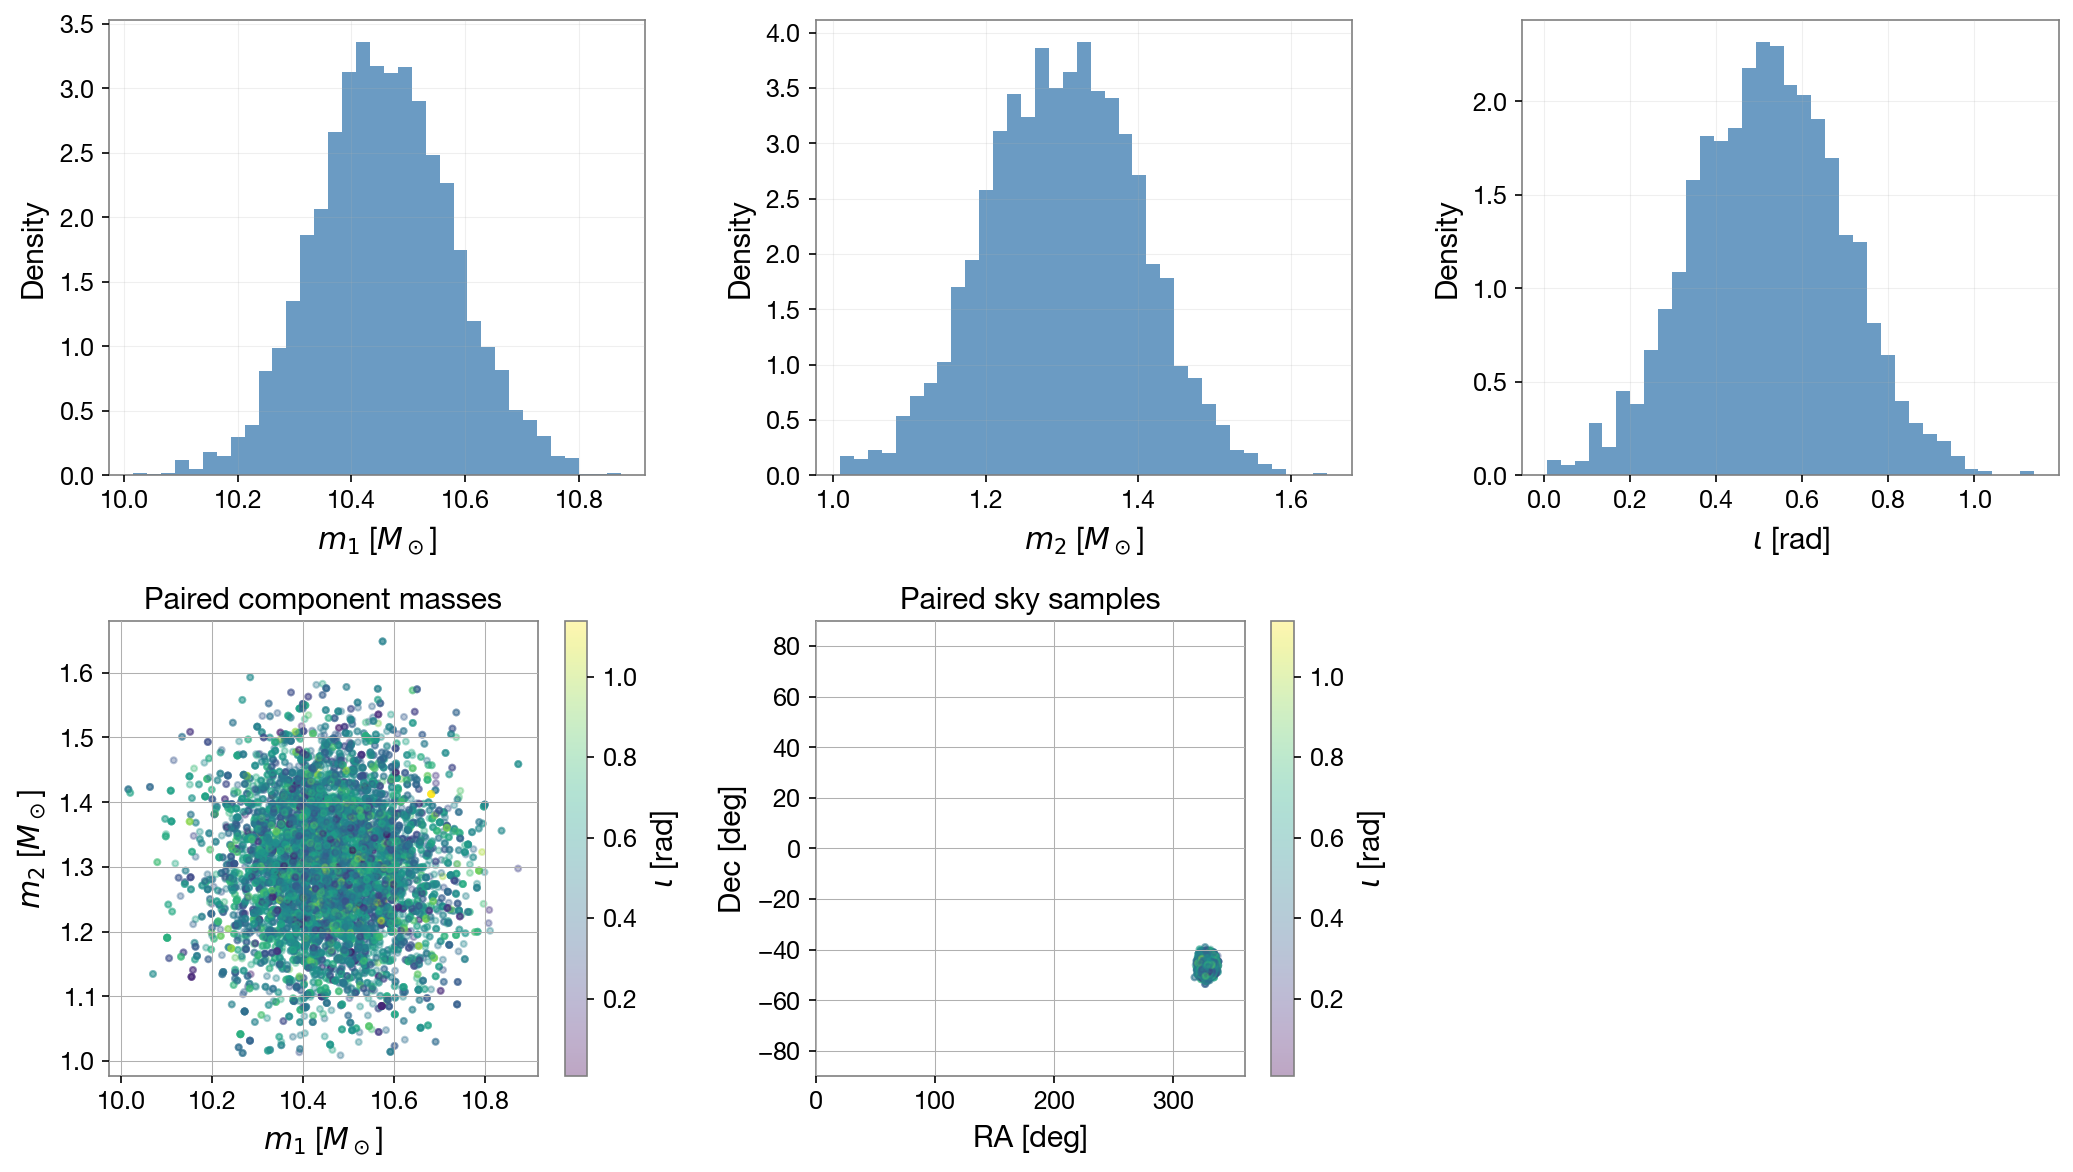

Sample plots saved to /Users/samueleronchini/.cache/gw_tdr_tutorial/GRB200228A/joint_source_sample_distributions.png


In [18]:
if joint_draws is None:
    print("No custom samples to plot. Set POSTERIOR_CSV to a valid sample CSV.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, column, label in zip(
        axes[0],
        ("m1", "m2", "iota_rad"),
        (r"$m_1$ [$M_\odot$]", r"$m_2$ [$M_\odot$]", r"$\iota$ [rad]"),
    ):
        ax.hist(joint_draws[column], bins=35, density=True, color="steelblue", alpha=0.8)
        ax.set_xlabel(label)
        ax.set_ylabel("Density")
        ax.grid(alpha=0.2)

    mass_scatter = axes[1, 0].scatter(
        joint_draws["m1"], joint_draws["m2"], c=joint_draws["iota_rad"],
        s=8, alpha=0.35, cmap="viridis",
    )
    axes[1, 0].set(xlabel=r"$m_1$ [$M_\odot$]", ylabel=r"$m_2$ [$M_\odot$]", title="Paired component masses")
    fig.colorbar(mass_scatter, ax=axes[1, 0], label=r"$\iota$ [rad]")

    sky_scatter = axes[1, 1].scatter(
        joint_draws["ra_deg"], joint_draws["dec_deg"], c=joint_draws["iota_rad"],
        s=8, alpha=0.35, cmap="viridis",
    )
    axes[1, 1].set(xlabel="RA [deg]", ylabel="Dec [deg]", title="Paired sky samples")
    axes[1, 1].set_xlim(0, 360)
    axes[1, 1].set_ylim(-90, 90)
    fig.colorbar(sky_scatter, ax=axes[1, 1], label=r"$\iota$ [rad]")
    axes[1, 2].axis("off")
    fig.tight_layout()
    joint_plot_path = OUTPUT_ROOT / "joint_source_sample_distributions.png"
    fig.savefig(joint_plot_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(joint_plot_path)))
    print(f"Sample plots saved to {joint_plot_path}")

### Estimate efficiency and map the custom-sample TDR

The next cell carries the sampled $m_1,m_2,\iota,\mathrm{RA},\mathrm{Dec}$ tuples through TDR's reference-SNR and effective-distance scaling, then plots a custom-sample efficiency curve and sky map with TDR's `plot_final`. The TDR checkout does not yet accept arbitrary joint posterior rows directly. Its saved BNS reference injections are available only at $(1,1)$, $(1.4,1.4)$, and $(2,2)\,M_\odot$; this notebook uses the **nearest reference mass pair** for each sampled mass. Thus the sky/orientation samples are propagated row-by-row, but the mass dependence is a discrete-template approximation, not a new waveform/SNR evaluation at each continuous sampled mass. The map marginalizes over the sample's masses and inclinations at every HEALPix location; the GRB localization is shown as the overlaid sky layer.

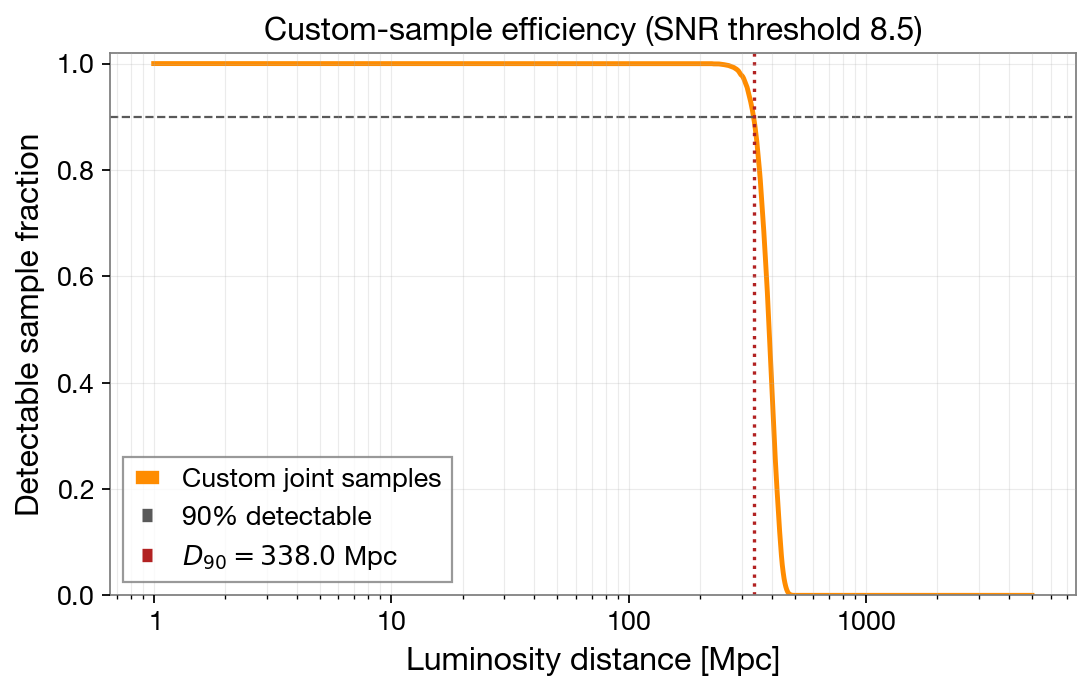

Custom-sample D90: 338.01 Mpc; efficiency plot: /Users/samueleronchini/.cache/gw_tdr_tutorial/GRB200228A/custom_joint_tdr/custom_sample_efficiency.png


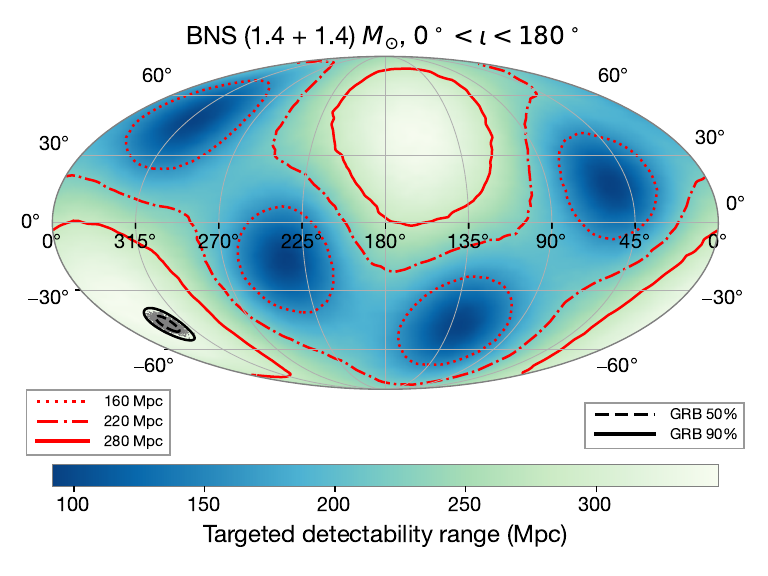

Custom-sample TDR map: /Users/samueleronchini/.cache/gw_tdr_tutorial/GRB200228A/custom_joint_tdr/range_map_bns_m1_1.4_m2_1.4.pdf


In [19]:
if joint_draws is None:
    print("No joint samples available. Set POSTERIOR_CSV and rerun the sample cells first.")
else:
    from targ_ac_git.aux_snr_mf import _convert_opt_to_mf_snr, _read_optimal_snr_file

    reference_templates = [(1.0, 1.0, "1", "1"), (1.4, 1.4, "1.4", "1.4"), (2.0, 2.0, "2.0", "2.0")]
    reference_masses = np.array([[item[0], item[1]] for item in reference_templates])
    reference_data = []
    sample_masses = joint_draws[["m1", "m2"]].to_numpy(dtype=float)
    template_index = np.argmin(
        np.sum(((sample_masses[:, None, :] - reference_masses[None, :, :]) / 0.4) ** 2, axis=2),
        axis=1,
    )

    custom_detectors = {ifo: Detector(ifo) for ifo in online_ifos}
    for m1_ref, m2_ref, m1_tag, m2_tag in reference_templates:
        reference_file = RUN_DIR / "results" / f"results_bns_m1_{m1_tag}_m2_{m2_tag}.hdf"
        ref_ifos, ref_snr, ref_ra, ref_dec, ref_t0 = _read_optimal_snr_file(str(reference_file))
        if sorted(ref_ifos) != sorted(online_ifos):
            raise ValueError(f"Detector mismatch in reference file {reference_file}: {ref_ifos}")
        reference_data.append({
            "snr": {ifo: float(np.asarray(ref_snr[ifo]).reshape(-1)[0]) for ifo in ref_ifos},
            "ref_eff": {
                ifo: float(custom_detectors[ifo].effective_distance(100.0, ref_ra, ref_dec, 0.0, ref_t0, 0.0))
                for ifo in ref_ifos
            },
        })

    def custom_network_snr(ra, dec, iota, polarization, template_ids):
        network_snr_sq = np.zeros(len(template_ids), dtype=float)
        for ifo in online_ifos:
            detector = custom_detectors[ifo]
            effective_distance = np.asarray(
                detector.effective_distance(100.0, ra, dec, polarization, T0, iota),
                dtype=float,
            )
            reference_snr = np.array([reference_data[index]["snr"][ifo] for index in template_ids])
            reference_distance = np.array([reference_data[index]["ref_eff"][ifo] for index in template_ids])
            scale = np.divide(
                reference_distance, effective_distance,
                out=np.zeros_like(effective_distance),
                where=np.isfinite(effective_distance) & (effective_distance > 0),
            )
            network_snr_sq += (reference_snr * scale) ** 2
        return np.sqrt(network_snr_sq)

    custom_rng = np.random.default_rng(20261009)
    sample_ra = np.deg2rad(joint_draws["ra_deg"].to_numpy(dtype=float))
    sample_dec = np.deg2rad(joint_draws["dec_deg"].to_numpy(dtype=float))
    sample_iota = joint_draws["iota_rad"].to_numpy(dtype=float)
    sample_polarization = custom_rng.uniform(0.0, 2.0 * np.pi, len(joint_draws))
    sample_template_ids = template_index
    sample_snr_opt = custom_network_snr(
        sample_ra, sample_dec, sample_iota, sample_polarization, sample_template_ids
    )
    if SNR_STATISTIC == "mf":
        sample_snr = _convert_opt_to_mf_snr(sample_snr_opt, len(online_ifos))
    else:
        sample_snr = sample_snr_opt

    sample_horizons = 100.0 * sample_snr / SNR_THRESHOLD
    distance_grid = np.logspace(0, np.log10(5000.0), 1000)
    sample_efficiency = np.mean(sample_horizons[:, None] > distance_grid[None, :], axis=0)
    d90_index = np.flatnonzero(sample_efficiency < 0.9)
    sample_d90 = float(distance_grid[d90_index[0]]) if len(d90_index) else float(distance_grid[-1])

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(distance_grid, sample_efficiency, color="darkorange", lw=2.2, label="Custom joint samples")
    ax.axhline(0.9, color="0.35", ls="--", lw=1, label="90% detectable")
    ax.axvline(sample_d90, color="firebrick", ls=":", lw=1.5, label=rf"$D_{{90}}={sample_d90:.1f}$ Mpc")
    ax.set(xscale="log", xlabel="Luminosity distance [Mpc]", ylabel="Detectable sample fraction", ylim=(0, 1.02))
    ax.set_title(f"Custom-sample efficiency (SNR threshold {SNR_THRESHOLD:g})")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    custom_output_dir = OUTPUT_ROOT / "custom_joint_tdr"
    custom_output_dir.mkdir(parents=True, exist_ok=True)
    efficiency_plot_path = custom_output_dir / "custom_sample_efficiency.png"
    fig.savefig(efficiency_plot_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(efficiency_plot_path)))
    print(f"Custom-sample D90: {sample_d90:.2f} Mpc; efficiency plot: {efficiency_plot_path}")

    map_rng = np.random.default_rng(20261010)
    map_sample_count = min(1000, len(joint_draws))
    map_indices = map_rng.choice(len(joint_draws), size=map_sample_count, replace=False)
    map_iota = sample_iota[map_indices]
    map_polarization = sample_polarization[map_indices]
    map_template_ids = sample_template_ids[map_indices]
    map_ra_pixels = np.deg2rad(tdr_aux.RA_PIX)
    map_dec_pixels = np.deg2rad(tdr_aux.DEC_PIX)
    custom_map = np.empty(len(map_ra_pixels), dtype=float)
    map_quantile_index = int(np.floor(0.1 * map_sample_count))

    for pixel_index, (ra_pixel, dec_pixel) in enumerate(zip(map_ra_pixels, map_dec_pixels)):
        pixel_snr_opt = custom_network_snr(
            np.full(map_sample_count, ra_pixel),
            np.full(map_sample_count, dec_pixel),
            map_iota,
            map_polarization,
            map_template_ids,
        )
        if SNR_STATISTIC == "mf":
            pixel_snr = _convert_opt_to_mf_snr(pixel_snr_opt, len(online_ifos))
        else:
            pixel_snr = pixel_snr_opt
        pixel_horizons = 100.0 * pixel_snr / SNR_THRESHOLD
        critical_horizon = np.partition(pixel_horizons, map_quantile_index)[map_quantile_index]
        grid_index = np.searchsorted(distance_grid, critical_horizon, side="left")
        custom_map[pixel_index] = distance_grid[grid_index] if grid_index < len(distance_grid) else 0.0

    map_fits_path = custom_output_dir / "range_map_bns_m1_1.4_m2_1.4.fits"
    tdr_aux.hp.write_map(str(map_fits_path), custom_map, nest=True, overwrite=True)
    tdr_aux.plot_final(
        str(custom_output_dir), str(map_fits_path), str(SKYMAP_FILE),
        [np.deg2rad(joint_draws["ra_deg"].to_numpy()), np.deg2rad(joint_draws["dec_deg"].to_numpy())],
        0.0, np.pi,
    )
    map_plot_path = custom_output_dir / "range_map_bns_m1_1.4_m2_1.4.pdf"
    assert map_plot_path.is_file(), f"TDR custom-sample map plot not found: {map_plot_path}"
    show_pdf(map_plot_path)
    print(f"Custom-sample TDR map: {map_plot_path}")